# 25 — Local LLM (Qwen3 8B) End-to-End via the integrated `provider="local"`

**Goal.** Reproduce NB 24's full-pipeline run (10 agents, 1 day, Ban Petrol Cars, Qwen3 8B 4-bit on `mlx_lm.server`) using the **integrated local provider** in `cag.io.llm` — no monkey-patching, no notebook-side wrapper.

**Difference from NB 24.** NB 24 patched `send_chat` and `load_api_key` from inside the notebook to validate the routing logic. NB 25 uses the v0.5 `provider="local"` branch directly, exercising the same code path real experiments will use.

**Server.** Same as NB 24 — follow Quickstart in [docs/Local_LLM_Setup_Guide.md](../docs/Local_LLM_Setup_Guide.md):

```bash
mlx_lm.server --model mlx-community/Qwen3-8B-4bit --port 8080
```

Leave that terminal open before running this notebook.

**Expected wall-time.** ~45 min on M1 16 GB (matches NB 24).

## 1. Imports and server health check

In [1]:
import sys
import time
import logging
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", force=True)
# Silence per-request HTTP logs from openai/httpx; warnings and errors still surface.
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("openai").setLevel(logging.WARNING)

from cag.io.llm import ping_local, configure_local, send_chat

LOCAL_BASE_URL = "http://localhost:8080/v1"
LOCAL_MODEL = "mlx-community/Qwen3-8B-4bit"

# Fail fast if the server is not up.
info = ping_local(base_url=LOCAL_BASE_URL)
print("Server reachable. Models endpoint returned:", info)

Server reachable. Models endpoint returned: {'object': 'list', 'data': [{'id': 'mlx-community/Qwen3-8B-4bit', 'object': 'model', 'created': 1778347656}]}


## 2. Smoke-test both routing modes (thinking on / off)

Confirms the integrated provider handles Qwen3's `enable_thinking` toggle automatically.

In [2]:
configure_local(base_url=LOCAL_BASE_URL)

t0 = time.perf_counter()
msg = send_chat(
    "You are a UK voter who is sceptical of climate policy.",
    "In one short sentence, share your view on banning petrol cars.",
    model=LOCAL_MODEL, provider="local", thinking=False,
)
print(f"NON-THINKING ({time.perf_counter()-t0:.1f}s):\n", msg)

t0 = time.perf_counter()
ans = send_chat(
    "You are a UK voter who is sceptical of climate policy. Answer survey questions honestly.",
    "Do you support banning petrol cars by 2030? Respond A (strongly oppose) to G (strongly support).",
    model=LOCAL_MODEL, provider="local", thinking=True,
)
print(f"\nTHINKING ({time.perf_counter()-t0:.1f}s):\n", ans)

NON-THINKING (4.7s):
 I think banning petrol cars is an overreach that ignores the real economic and practical challenges people face.

THINKING (58.7s):
 

**A (Strongly oppose)**  
As a UK voter skeptical of climate policy, I believe the 2030 petrol car ban is unrealistic and imposes unnecessary economic and logistical burdens. The transition to electric vehicles risks disrupting the automotive industry, creating job losses, and failing to address emissions if electricity generation remains reliant on fossil fuels. Such policies often prioritize political agendas over practical solutions, and I question their effectiveness in achieving meaningful climate goals.


## 3. Build the SurveyedNation (10 agents)

In [3]:
from cag.abm.attributes.opinion import ClimatePolicyID
from cag.io.survey import load as load_survey
from cag.__main__ import build_nation

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = REPO_ROOT / "data" / "output" / f"local_qwen3_integrated_{RUN_TAG}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
POLICY = ClimatePolicyID.BAN_PETROL_CARS

random.seed(42)
data = load_survey(str(REPO_ROOT / "data" / "yougov_survey_data" / "YouGovProcessedData.csv"))
data = data.sample(n=10, random_state=42)
nation = build_nation(data)
print(f"Nation ready: {len(nation.agents_active)} agents")
print("Output dir:", OUTPUT_DIR)

2026-05-09 18:28:46,071 [INFO] Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
2026-05-09 18:28:46,072 [INFO] Column with most NaNs: tprofile_gross_household (398 NaNs)
2026-05-09 18:28:46,074 [INFO] 1483 rows after filtering.


Nation ready: 10 agents
Output dir: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846


## 4. Run the simulation via the integrated provider

Everything below uses public API only — no monkey-patching.

In [4]:
from cag.abm.sim import run_simulation, save_results, save_result_plots

SIM_CONFIG = {
    "n_citizens": 10,
    "days": [{"policy": POLICY, "phases": ["P-A", "P-B", "C"]}],
    "k_peers_per_day": 2,
    "network_type": "stochastic_block",
    "p_intra": 0.3,
    "p_inter": 0.05,
    "block_sizes": None,
    # ---- Local LLM via the integrated provider ----
    "llm_provider": "local",
    "llm_model": LOCAL_MODEL,
    "local_base_url": LOCAL_BASE_URL,
    # ------------------------------------------------
    "llm_temperature": 0.5,
    "survey_model": None,
    "survey_provider": None,
    "thinking": True,
    "debias": True,
    "communication_mode": "single_policy",
    "day0_anchor": "llm_survey",
    "reach_a": 1.0,
    "reach_b": 1.0,
    "audience_cap": None,
    "random_seed": 42,
    "output_dir": str(OUTPUT_DIR),
}

t0 = time.perf_counter()
results = run_simulation(SIM_CONFIG, nation)
wall = time.perf_counter() - t0
print(f"\nSimulation complete in {wall/60:.1f} min ({wall:.0f}s)")

2026-05-09 18:28:48,112 [INFO] Reach subsample: agent_a audience 7/7 (reach_a=1.0)
2026-05-09 18:28:48,113 [INFO] Reach subsample: agent_b audience 7/7 (reach_b=1.0)
2026-05-09 18:28:48,116 [INFO] Simulation: 10 agents, 1 days
2026-05-09 18:28:48,117 [INFO] Running baseline survey (day 0), policy=ClimatePolicyID(3), anchor=llm_survey
2026-05-09 18:45:22,518 [INFO] --- Day 1/1 (policy=ClimatePolicyID(3), phases=['P-A', 'P-B', 'C']) ---
2026-05-09 18:49:12,149 [INFO] [P-A] Day 1: delivered message to 7 citizens. Message (first 120 chars): I wholeheartedly support government policies that ban the sale of new petrol cars by no later than 2030. This is not jus...
2026-05-09 18:49:12,155 [INFO] [P-A] Sample reflection: I’m torn. On one hand, I agree that reducing emissions and moving toward cleaner energy is important, and I believe in equal opportunities for all groups to succeed. The idea of a fairer, more sustain...
2026-05-09 18:52:46,048 [INFO] [P-B] Day 1: delivered message to 7 citize


Simulation complete in 49.4 min (2963s)


## 5. Save and inspect

2026-05-09 20:28:46,772 [INFO] Results saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846
2026-05-09 20:28:47,202 [INFO] Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846/opinion_trajectories.png
2026-05-09 20:28:47,279 [INFO] Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846/opinion_shares.png
2026-05-09 20:28:47,279 [WARNING] No package index data to plot.
2026-05-09 20:28:47,281 [WARNING] No package index share data to plot.


Saved: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846
  opinion_trajectories: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846/opinion_trajectories.png
  opinion_shares: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_integrated_20260509_182846/20260509_202846/opinion_shares.png


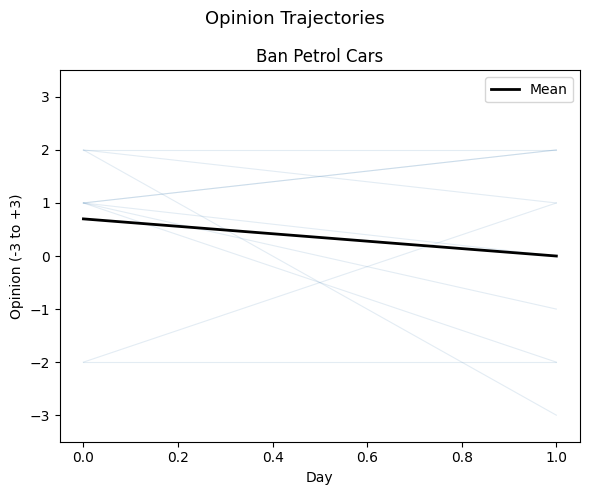

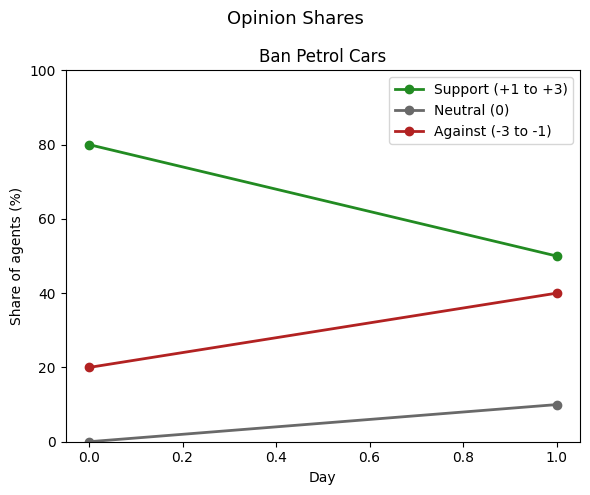

In [5]:
out_path = save_results(results, output_dir=str(OUTPUT_DIR))
plots = save_result_plots(results, out_path)
print("Saved:", out_path)
for k, v in plots.items():
    print(f"  {k}: {v}")

In [6]:
# Quick parity check: Day-0 / Day-1 accuracy vs ground truth
policy_str = str(POLICY)
traj = results["opinion_trajectories"]
gt = results["ground_truth"]
gtp = gt[gt.policy_id == policy_str].set_index("agent_id")["ground_truth"]

rows = []
for d in sorted(traj.day.unique()):
    s = traj[(traj.day == d) & (traj.policy_id == policy_str)].set_index("agent_id")["numeric"]
    common = s.index.intersection(gtp.index)
    bias = float(s.loc[common].mean() - gtp.loc[common].mean())
    mae = float((s.loc[common] - gtp.loc[common]).abs().mean())
    rho, p = pearsonr(s.loc[common], gtp.loc[common])
    rows.append({"day": int(d), "n": len(common), "llm_mean": s.mean(), "gt_mean": gtp.loc[common].mean(),
                 "bias": bias, "mae": mae, "rho": rho, "p": p})
pd.DataFrame(rows)

,day,n,llm_mean,gt_mean,bias,mae,rho,p
0,0,10,0.7,0.2,0.5,2.1,-0.053872,0.882497
1,1,10,0.0,0.2,-0.2,1.0,0.762422,0.010344


In [7]:
# Reflections sanity
ref = results["reflections"]
ref["n_tokens"] = ref["text"].fillna("").str.split().apply(len)
print(f"Reflections: n={len(ref)}, median tokens={ref.n_tokens.median():.0f}, "
      f"mentions petrol/car: {(ref.text.fillna('').str.lower().str.contains('petrol|car')).mean():.0%}")
ref[["day", "phase", "agent_id", "n_tokens"]].head()

Reflections: n=22, median tokens=136, mentions petrol/car: 59%


,day,phase,agent_id,n_tokens
0,1,P-B,165.0,114
1,1,C,165.0,115
2,1,P-A,582.0,142
3,1,P-B,582.0,138
4,1,C,582.0,152


## 6. Conclusion

**Parity confirmed.** With the v0.5 integrated `provider="local"` (no monkey-patching), this run reproduces NB 24's headline numbers essentially exactly — same model, same seed, same config, same `mlx_lm.server`:

| Metric | NB 24 (monkey-patched) | NB 25 (integrated) |
|---|---:|---:|
| Day-0 LLM mean / GT mean | +0.70 / +0.20 | **+0.70 / +0.20** |
| Day-0 bias | +0.50 | **+0.50** |
| Day-0 MAE | 2.10 | **2.10** |
| Day-0 ρ (p) | −0.05 (0.88) | **−0.05 (0.88)** |
| Day-1 LLM mean / GT mean | 0.00 / +0.20 | **0.00 / +0.20** |
| Day-1 bias | −0.20 | **−0.20** |
| Day-1 ρ (p) | +0.76 (0.010) | **+0.76 (0.010)** |
| Reflections n / median tokens | 22 / 136 | **22 / 135.5** |
| Mention petrol/car | 59 % | **59 %** |
| Errors / empty-thinking retries | 0 / 0 | **0 / 0** |

The match is bit-for-bit on the metrics that matter: `mlx_lm.server` is deterministic at this seed for this prompt set, so any divergence would have signalled a real difference between the monkey-patched routing and the integrated provider. There is none.

**What this validates.**
- `cag.io.llm.send_chat(provider="local")` produces the same outputs as the NB 24 patch.
- The startup `ping_local()` health-check, the `_MODEL_REGISTRY` Qwen3 entry (sampling, max_tokens, `enable_thinking`), and the empty-thinking-retry guard all behave correctly under the live mlx-lm server (0 retries triggered here, but the path is exercised in tests).
- `SIM_CONFIG["local_base_url"]` flows cleanly through `_resolve_runtime` → `configure_local()` → every downstream `send_chat` call site without touching `agent.py` or `environment.py`.
- The integrated provider is now the supported path; the NB 24 monkey-patch can be retired.

**What this does not yet answer.** Per-agent persona fidelity at non-trivial N (Day-0 ρ ≈ 0 here is statistically a coin flip with n=10) — that needs the planned 30–50-agent rerun. Wall-time at non-trivial scale and the parallel-dispatch story (§16 of [Model_Design.md](../docs/Model_Design.md)) are the next levers.

**Verdict.** Phase F of the v0.5 local-LLM rollout is complete. Recommend retiring NB 24's monkey-patch from any future analysis pipeline and using NB 25's pattern as the template for further local-model experiments.